### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Qwen's open source LLM [Qwen 2.5-7B](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct) for prompting

Furthermore, we will perform our experiments on the [Yahoo Answers Topics Dataset](https://huggingface.co/datasets/community-datasets/yahoo_answers_topics).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("community-datasets/yahoo_answers_topics", split="train") 
test_data = load_dataset("community-datasets/yahoo_answers_topics", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 1400000 examples
Test set size: 60000 examples


In [3]:
# get the label names:
label_names = train_data.features['topic'].names

# rename some labels for clarity:
label_names = [name.replace("Society & Culture", "Culture") for name in label_names]
label_names = [name.replace("Science & Mathematics", "Science") for name in label_names]
label_names = [name.replace("Education & Reference", "Education") for name in label_names]
label_names = [name.replace("Computers & Internet", "Tech") for name in label_names]
label_names = [name.replace("Business & Finance", "Business") for name in label_names]
label_names = [name.replace("Entertainment & Music", "Entertainment") for name in label_names]
label_names = [name.replace("Family & Relationships", "Family") for name in label_names]
label_names = [name.replace("Politics & Government", "Politics") for name in label_names]

# create a mapping from index to label:
index2label = {i: name for i, name in enumerate(label_names)}
index2label

{0: 'Culture',
 1: 'Science',
 2: 'Health',
 3: 'Education',
 4: 'Tech',
 5: 'Sports',
 6: 'Business',
 7: 'Entertainment',
 8: 'Family',
 9: 'Politics'}

In [4]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter all the questions_content that are empty strings:
train_df = train_df[train_df['question_content'].str.strip().astype(bool)]
test_df = test_df[test_df['question_content'].str.strip().astype(bool)]

train_df.sample()

,id,topic,question_title,question_content,best_answer
498704,498704,3,do i receive credit for my foreign studies in ...,i receive a bachelor degree in manila will my ...,Some credits count depending on the university...


In [5]:
from sklearn.model_selection import train_test_split

# sample 5k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["topic"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["topic"], train_size=1000, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 2000 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [6]:
# map numeric labels to string labels:
train_df['label'] = train_df['topic'].map(index2label)
test_df['label'] = test_df['topic'].map(index2label)

In [7]:
# select input and label from data:
X_train = train_df['question_content'].to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df['question_content'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  10


### Sparse Frequency-based Embeddings for Similarity

We import TfidfVectorizer from `sklearn.feature_extraction.text` and use it to create and fit a TF-IDF input embedding on the `X_train` data. Since `TfidfVectorizer.transform(...)` returns a sparse matrix.

In [8]:
from sentence_transformers import SentenceTransformer

# load MiniLM model
minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# define embedding function
phi = lambda x: minilm.encode(x, convert_to_numpy=True)

# test embedding shape
phi(X_train[:2]).shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 384)

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [9]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'Business': 0,
 'Culture': 1,
 'Education': 2,
 'Entertainment': 3,
 'Family': 4,
 'Health': 5,
 'Politics': 6,
 'Science': 7,
 'Sports': 8,
 'Tech': 9}

In [10]:
from sklearn.metrics import pairwise_distances

def get_few_shot_examples(text, examples_per_class=2):

    examples = []

    for label in np.unique(y_train):

        texts = X_train[y_train == label]

        embeddings = phi([text] + texts.tolist())

        similarity = (1. - pairwise_distances(embeddings, metric='cosine'))[1:,0]

        for j in np.argsort(similarity)[::-1][:examples_per_class]:
            examples.append((texts[j], label, similarity[j]))

    examples.sort(key=lambda e: e[2], reverse=True)

    return examples

In [11]:
t = X_test[0]  # test text
n = 1          # shots
similar_examples = get_few_shot_examples(t, examples_per_class=n)
print(f"Most similar train samples for the first test sample\n'{X_test[0]}' (n={n}):\n")
for i, (text, label, sim) in enumerate(similar_examples): print(i+1, text)

Most similar train samples for the first test sample
'Hitler censored Eric Maria Remarque's All Quiet on the western front. Which details in the novel would cause Hitler to take such action? Considering Hitler's goals, was he justified in censoring the novel?' (n=1):

1 Do you really believe it was God the author was communicating with? What about some of the things that are totally out of line with the Bible?
2 1. wrtie whether or not the movie is ethical\n2. write if the movie follows moral standars
3 THE BOOK WAS PRINTED IN THE U.K.
4 I am not looking for an answer based on the best story book ever, called the bible, i am referring to an intelligent response which the theory of evolution poses to God's role, namely concerning him as a creator.
5 The story is very interesting and truth, just writing angel blancia in yahoo searching.
6 i am doing a project on the book "To Kill a Mockingbird". i have to find a song that has to do with the theme. some possibilities are manhood, pride, o

### Instantiate Qwen

In order to be able to use huggingface's Qwen 2.5 models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct)).

In [12]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 7B parameter version of Qwen 2.5.

In [13]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-7B-Instruct",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
    trust_remote_code=True
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

### Results Handling Helper

In [14]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [15]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Few-shot learning with Most Similar Examples (Sparse Embeddings)

Generate a prompt for classification using a given text and $n$ labeled examples.

In [16]:
def get_prompt(text, shots):
    replace_qm = lambda s: s.replace('"', "'")
    prompt = 'We classify user questions into topic categories based on their text. Here are some labelled examples:\n'
    for x,y in shots: prompt += f'\n"{replace_qm(x)}" => {y}'
    return {"role": "user", "content": f'{prompt}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

shots_examples = get_few_shot_examples(X_test[0], examples_per_class=n)
shots = [(x, y) for x, y, _ in shots_examples]
prompt = get_prompt(X_test[0], shots)["content"]
print(prompt)

We classify user questions into topic categories based on their text. Here are some labelled examples:

"Do you really believe it was God the author was communicating with? What about some of the things that are totally out of line with the Bible?" => Culture
"1. wrtie whether or not the movie is ethical\n2. write if the movie follows moral standars" => Politics
"THE BOOK WAS PRINTED IN THE U.K." => Health
"I am not looking for an answer based on the best story book ever, called the bible, i am referring to an intelligent response which the theory of evolution poses to God's role, namely concerning him as a creator." => Science
"The story is very interesting and truth, just writing angel blancia in yahoo searching." => Sports
"i am doing a project on the book 'To Kill a Mockingbird'. i have to find a song that has to do with the theme. some possibilities are manhood, pride, or equality. does anyone know any songs that have to do with any of those? serious answers please. if you have an

In [17]:
from tqdm import tqdm
import numpy as np

def few_shot_learning_batch(test, y_train, n=2):
  outputs = []
  prompt_lengths = []
  input_lengths = []
  shots_lengths = []
  num_shots = []
  for i, t in tqdm(enumerate(test), total=len(test)):
      shots_examples = get_few_shot_examples(t, examples_per_class=n)
      shots = [(x, y) for x, y, _ in shots_examples]

      num_shots.append(len(shots))

      prompt = get_prompt(t, shots)
      
      prompt_len = len(llm.tokenizer(prompt["content"])["input_ids"])
      input_len = len(llm.tokenizer(t)["input_ids"])
      shots_text = "\n".join([x for x,_ in shots])
      shots_len = len(llm.tokenizer(shots_text)["input_ids"])
      
      prompt_lengths.append(prompt_len)
      input_lengths.append(input_len)
      shots_lengths.append(shots_len)
      
      outputs.append(llm([prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"])
      
  return outputs, prompt_lengths, input_lengths, shots_lengths, num_shots


predictions, prompt_lengths, input_lengths, shots_lengths, num_shots = few_shot_learning_batch(
    X_test, y_train, n=1
)

print(f"Average prompt length: {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length: {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")

  0%|          | 0/1000 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'top_p', 'temperature', 'bos_token_id', 'max_new_tokens', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  0%|          | 1/1000 [00:01<22:59,  1.38s/it]

...

100%|█████████▉| 999/1000 [17:53<00:01,  1.07s/it]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


100%|██████████| 1000/1000 [17:54<00:00,  1.04s/it]

100%|██████████| 1000/1000 [17:54<00:00,  1.07s/it]

Average prompt length: 538.2 tokens
Average input length: 50.9 tokens
Average shots section length: 413.8 tokens


In [18]:
predictions[:10]

['History',
 'Family',
 'Entertainment',
 'Family',
 'Politics',
 'Health',
 'Science',
 'Tech',
 'Tech',
 'Family']

Classification Report:
                precision    recall  f1-score   support

       Health       0.59      0.80      0.68       104
      Culture       0.54      0.34      0.42       111
      Science       0.69      0.38      0.49        87
    Education       0.36      0.56      0.44        95
     Business       0.52      0.39      0.45        85
       Sports       0.85      0.66      0.74        83
       Family       0.66      0.35      0.46       120
Entertainment       0.56      0.67      0.61       106
     Politics       0.67      0.45      0.54       107
         Tech       0.79      0.75      0.77       102

    micro avg       0.60      0.53      0.56      1000
    macro avg       0.62      0.53      0.56      1000
 weighted avg       0.62      0.53      0.56      1000

Accuracy: 0.532


Text(0.5, 1.0, 'Confusion Matrix')

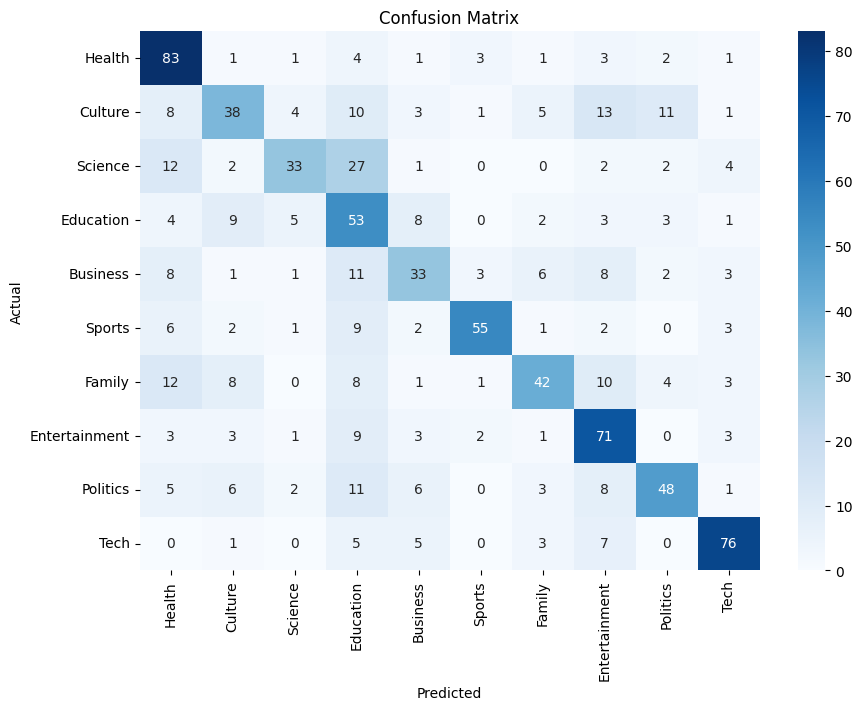

In [19]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [20]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/predictions/yahoo-qwen-2.5-7b-fewshot-minilm-2.0k-samples-2-shots-pc.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/predictions/yahoo-qwen-2.5-7b-fewshot-minilm-2.0k-samples-2-shots.json'


In [21]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/lengths/yahoo-qwen-2.5-7b-fewshot-minilm-2.0k-samples-2-shots-pc.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/yahoo-answers/results/lengths/yahoo-qwen-2.5-7b-fewshot-minilm-2.0k-samples-2-shots.json'
